# Notebook 3 — Priority Prediction

## Objective
Predict the urgency level of a consumer complaint — **High**, **Medium**, or **Low** — using the complaint text.

This notebook is the second half of the support ticket classification pipeline. Once a ticket is routed to the right team (Notebook 2), the priority model tells that team how urgently they need to respond.

## What makes priority prediction harder than category classification
Category classification has clear vocabulary signals — a complaint mentioning "Equifax" almost certainly belongs to Credit Reporting. Priority prediction is more subtle. The same words can appear in both a High and Medium priority complaint — what matters is the **intensity**, **legal implications**, and **financial severity** of the language used.

This notebook documents two approaches to priority label engineering and compares their results:
1. **Keyword-based labels** — priority derived from presence of urgency keywords
2. **Keyword + Sentiment labels** — priority derived from keywords AND emotional intensity of the complaint

---

In [1]:
# Cell 1 — Setup & Imports
import os
os.chdir('..')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import LinearSVC
from sklearn.calibration import CalibratedClassifierCV
from sklearn.metrics import (
    accuracy_score, classification_report,
    confusion_matrix, ConfusionMatrixDisplay
)
from sklearn.preprocessing import LabelEncoder
from scipy.sparse import hstack, csr_matrix
import joblib

# Sentiment libraries
from vaderSentiment.vaderSentiment import SentimentIntensityAnalyzer

print('All imports successful')

All imports successful


In [2]:
# Cell 2 — Load Cleaned Data
df = pd.read_csv('data/cleaned_tickets.csv')
df = df.dropna(subset=['cleaned_text'])
df['cleaned_text'] = df['cleaned_text'].astype(str)
df['combined_text'] = df['combined_text'].astype(str)

print(f'Dataset shape: {df.shape}')
print(f'\nColumns: {df.columns.tolist()}')
print(f'\nPriority distribution:')
print(df['priority'].value_counts())
df.head(3)

Dataset shape: (21221, 4)

Columns: ['product_5', 'priority', 'combined_text', 'cleaned_text']

Priority distribution:
priority
High      7100
Medium    7099
Low       7022
Name: count, dtype: int64


,product_5,priority,combined_text,cleaned_text
0,Bank Accounts and Services,High,I have been misled by BECU on numerous occasio...,misled becu numerous occasion regarding charge...
1,Debt Collection,Low,On XX/XX/XXXX I attempted to use my debit card...,attempted use debit card make purchase decline...
2,Debt Collection,High,I was an XXXXXXXX XXXX at XXXX XXXX XXXX in XX...,awarded washington need grant last quarter sem...


---
## Approach 1 — Keyword-Based Priority Labels

### Design rationale
The dataset has no built-in priority column so we engineer it. The first approach assigns priority based on the presence of urgency keywords in the complaint text and issue description.

**Logic:**
- **High** — 2 or more high-urgency signals (fraud, theft, legal violation, unauthorized access)
- **Medium** — exactly 1 high-urgency signal, or no signals of either type
- **Low** — presence of low-urgency signals (general inquiry, status update, clarification)

### Why keyword counting rather than single keyword matching?
A single keyword can appear incidentally — someone might mention "fraud" in passing without the complaint being High priority. Requiring 2+ signals reduces false positives and produces more reliable labels.

### Known limitation
This approach treats all keywords equally regardless of context. The word "error" in "I made an error" is not the same severity as "there is an error on my credit report affecting my mortgage application". This is the motivation for Approach 2.

---

In [3]:
# Cell 3 — Approach 1: Keyword-Based Priority Labels

def assign_priority_keywords(row):
    issue = str(row.get('Issue', '')).lower() if 'Issue' in row.index else ''
    narrative = str(row['combined_text']).lower()
    combined = issue + ' ' + narrative

    high_keywords = [
        'fraud', 'theft', 'stolen', 'unauthorized', 'identity theft',
        'scam', 'illegal', 'violation', 'discriminat', 'lawsuit',
        'attorney', 'legal action', 'incorrect information',
        'wrongful', 'harassment', 'threaten'
    ]
    low_keywords = [
        'question', 'inquiry', 'information', 'how do i', 'wondering',
        'curious', 'would like to know', 'general', 'clarification'
    ]

    high_count = sum(1 for kw in high_keywords if kw in combined)
    low_count  = sum(1 for kw in low_keywords  if kw in combined)

    if high_count >= 2:
        return 'High'
    elif high_count == 1:
        return 'Medium'
    elif low_count >= 1:
        return 'Low'
    else:
        return 'Medium'

df['priority_keywords'] = df.apply(assign_priority_keywords, axis=1)

print('Keyword-based priority distribution:')
print(df['priority_keywords'].value_counts())

Keyword-based priority distribution:
priority_keywords
Medium    10054
Low        6327
High       4840
Name: count, dtype: int64


---
## Approach 2 — Keyword + Sentiment-Based Priority Labels

### Motivation
Keyword counting ignores the emotional intensity of a complaint. Consider these two sentences:
- *"There may be an unauthorized charge on my account"* — mentions unauthorized, but tone is uncertain
- *"Someone has completely drained my account through unauthorized withdrawals and I am devastated"* — same keyword, but far more urgent in tone

VADER (Valence Aware Dictionary and sEntiment Reasoner) is a sentiment analysis tool specifically designed for informal text like complaints. It produces a **compound score** from -1 (extremely negative) to +1 (extremely positive).

### Enhanced logic
- **High** — 2+ high keywords, OR (1 high keyword AND compound sentiment ≤ -0.5)
- **Medium** — 1 high keyword with mild sentiment, OR strong negative sentiment alone
- **Low** — low urgency keywords AND neutral/positive sentiment

### Why VADER over TextBlob?
VADER is specifically tuned for short, emotionally charged text like customer complaints. It understands capitalization ("FRAUD" vs "fraud"), punctuation emphasis ("unauthorized!!!"), and negations ("never resolved"). TextBlob is better suited for longer, formal text.

---

In [4]:
# Cell 4 — Compute VADER Sentiment Scores
analyzer = SentimentIntensityAnalyzer()

def get_sentiment_scores(text):
    scores = analyzer.polarity_scores(str(text))
    return pd.Series({
        'vader_compound': scores['compound'],
        'vader_negative': scores['neg'],
        'vader_positive': scores['pos'],
        'vader_neutral' : scores['neu']
    })

# Apply to raw combined_text (not cleaned) — VADER works better on original text
# because it uses punctuation and capitalization as intensity signals
print('Computing sentiment scores (this may take 30-60 seconds)...')
sentiment_df = df['combined_text'].apply(get_sentiment_scores)
df = pd.concat([df, sentiment_df], axis=1)

print('Done.')
print(f'\nSentiment score statistics:')
print(df[['vader_compound', 'vader_negative', 'vader_positive']].describe().round(3))

print(f'\nSample sentiment scores:')
for i in range(3):
    print(f'\n[{i}] {df["combined_text"][i][:100]}...')
    print(f'    Compound: {df["vader_compound"][i]:.3f} | Negative: {df["vader_negative"][i]:.3f}')

Computing sentiment scores (this may take 30-60 seconds)...
Done.

Sentiment score statistics:
       vader_compound  vader_negative  vader_positive
count       21221.000       21221.000       21221.000
mean           -0.077           0.078           0.073
std             0.705           0.054           0.050
min            -1.000           0.000           0.000
25%            -0.784           0.042           0.038
50%            -0.151           0.069           0.065
75%             0.637           0.106           0.100
max             1.000           0.610           0.464

Sample sentiment scores:

[0] I have been misled by BECU on numerous occasions regarding a charge dispute for authorized purchase ...
    Compound: -0.748 | Negative: 0.068

[1] On XX/XX/XXXX I attempted to use my debit card to make a purchase and it was declined. At that time ...
    Compound: -0.972 | Negative: 0.068

[2] I was an XXXXXXXX XXXX at XXXX XXXX XXXX in XXXX. I was awarded a Washington XXXX need grant

In [5]:
# Cell 5 — Approach 2: Keyword + Sentiment Priority Labels

def assign_priority_sentiment(row):
    narrative  = str(row['combined_text']).lower()
    compound   = row['vader_compound']
    neg_score  = row['vader_negative']

    high_keywords = [
        'fraud', 'theft', 'stolen', 'unauthorized', 'identity theft',
        'scam', 'illegal', 'violation', 'discriminat', 'lawsuit',
        'attorney', 'legal action', 'incorrect information',
        'wrongful', 'harassment', 'threaten'
    ]
    low_keywords = [
        'question', 'inquiry', 'information', 'how do i', 'wondering',
        'curious', 'would like to know', 'general', 'clarification'
    ]

    high_count = sum(1 for kw in high_keywords if kw in narrative)
    low_count  = sum(1 for kw in low_keywords  if kw in narrative)

    # High: multiple urgency signals OR one signal with very negative sentiment
    if high_count >= 2:
        return 'High'
    elif high_count == 1 and compound <= -0.5:
        return 'High'
    # Medium: one urgency signal with mild sentiment OR very negative tone alone
    elif high_count == 1:
        return 'Medium'
    elif compound <= -0.6 and neg_score >= 0.15:
        return 'Medium'
    # Low: low urgency signals AND neutral/positive sentiment
    elif low_count >= 1 and compound >= -0.2:
        return 'Low'
    else:
        return 'Medium'

df['priority_sentiment'] = df.apply(assign_priority_sentiment, axis=1)

print('Keyword + Sentiment priority distribution:')
print(df['priority_sentiment'].value_counts())

print('\nComparison — Keyword vs Keyword+Sentiment:')
comparison = pd.DataFrame({
    'Keyword Only'     : df['priority_keywords'].value_counts(),
    'Keyword+Sentiment': df['priority_sentiment'].value_counts()
})
print(comparison)

Keyword + Sentiment priority distribution:
priority_sentiment
Medium    10795
High       6619
Low        3807
Name: count, dtype: int64

Comparison — Keyword vs Keyword+Sentiment:
        Keyword Only  Keyword+Sentiment
High            4840               6619
Low             6327               3807
Medium         10054              10795


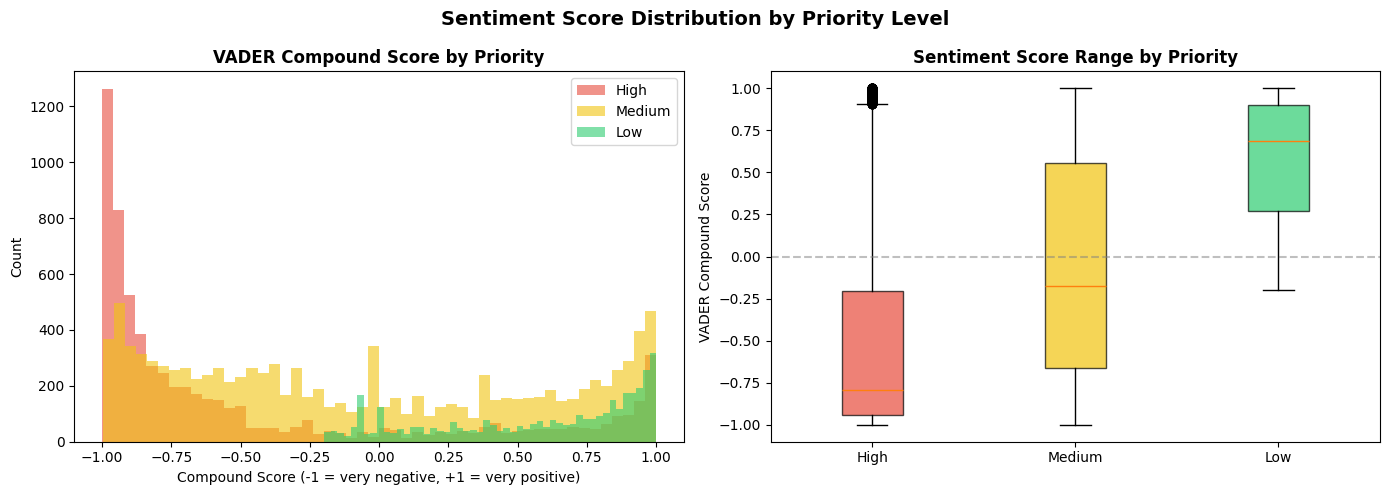

Sentiment distribution plot saved.


In [6]:
# Cell 6 — Visualize Sentiment Score Distribution by Priority
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Sentiment Score Distribution by Priority Level', 
             fontsize=14, fontweight='bold')

colors = {'High': '#e74c3c', 'Medium': '#f1c40f', 'Low': '#2ecc71'}

# Compound score distribution
for priority in ['High', 'Medium', 'Low']:
    subset = df[df['priority_sentiment'] == priority]['vader_compound']
    axes[0].hist(subset, bins=50, alpha=0.6, label=priority, 
                 color=colors[priority])
axes[0].set_title('VADER Compound Score by Priority', fontweight='bold')
axes[0].set_xlabel('Compound Score (-1 = very negative, +1 = very positive)')
axes[0].set_ylabel('Count')
axes[0].legend()

# Box plot
priority_order = ['High', 'Medium', 'Low']
data_to_plot = [df[df['priority_sentiment'] == p]['vader_compound'].values 
                for p in priority_order]
bp = axes[1].boxplot(data_to_plot, labels=priority_order, patch_artist=True)
for patch, priority in zip(bp['boxes'], priority_order):
    patch.set_facecolor(colors[priority])
    patch.set_alpha(0.7)
axes[1].set_title('Sentiment Score Range by Priority', fontweight='bold')
axes[1].set_ylabel('VADER Compound Score')
axes[1].axhline(0, color='gray', linestyle='--', alpha=0.5)

plt.tight_layout()
plt.savefig('data/sentiment_distribution.png', dpi=150, bbox_inches='tight')
plt.show()
print('Sentiment distribution plot saved.')

---
## Model Training — Two Experiments

We train the same three models (Logistic Regression, Random Forest, LinearSVC) twice:
- **Experiment A** — TF-IDF features only, keyword-based labels
- **Experiment B** — TF-IDF + sentiment features, keyword+sentiment labels

This lets us directly measure whether adding sentiment scores improves model performance.

### Feature matrix construction for Experiment B
We combine TF-IDF vectors (5000 features) with 4 sentiment scores (compound, negative, positive, neutral) using `scipy.sparse.hstack`. This creates a 5004-feature matrix where the model can learn from both text content and emotional tone simultaneously.

---

In [7]:
# Cell 7 — Experiment A: TF-IDF Only + Keyword Labels
print('=' * 50)
print('EXPERIMENT A: TF-IDF Only + Keyword Labels')
print('=' * 50)

X = df['cleaned_text']
le_a = LabelEncoder()
y_a = le_a.fit_transform(df['priority_keywords'])

tfidf_a = TfidfVectorizer(
    max_features=5000,
    ngram_range=(1, 2),
    min_df=2,
    sublinear_tf=True
)
X_tfidf_a = tfidf_a.fit_transform(X)

X_train_a, X_test_a, y_train_a, y_test_a = train_test_split(
    X_tfidf_a, y_a, test_size=0.2, random_state=42, stratify=y_a
)

# Train all three models
lr_a  = LogisticRegression(max_iter=1000, C=1.0, random_state=42)
rf_a  = RandomForestClassifier(n_estimators=200, min_samples_split=5, 
                                random_state=42, n_jobs=-1)
svm_a = CalibratedClassifierCV(LinearSVC(C=1.0, max_iter=2000, random_state=42))

lr_a.fit(X_train_a, y_train_a)
rf_a.fit(X_train_a, y_train_a)
svm_a.fit(X_train_a, y_train_a)

lr_acc_a  = accuracy_score(y_test_a, lr_a.predict(X_test_a))
rf_acc_a  = accuracy_score(y_test_a, rf_a.predict(X_test_a))
svm_acc_a = accuracy_score(y_test_a, svm_a.predict(X_test_a))

print(f'Logistic Regression : {lr_acc_a*100:.2f}%')
print(f'Random Forest       : {rf_acc_a*100:.2f}%')
print(f'LinearSVC           : {svm_acc_a*100:.2f}%')

EXPERIMENT A: TF-IDF Only + Keyword Labels
Logistic Regression : 83.89%
Random Forest       : 89.23%
LinearSVC           : 85.82%


In [8]:
# Cell 8 — Experiment B: TF-IDF + Sentiment Features + Keyword+Sentiment Labels
print('=' * 50)
print('EXPERIMENT B: TF-IDF + Sentiment + Keyword+Sentiment Labels')
print('=' * 50)

le_b = LabelEncoder()
y_b = le_b.fit_transform(df['priority_sentiment'])

tfidf_b = TfidfVectorizer(
    max_features=5000,
    ngram_range=(1, 2),
    min_df=2,
    sublinear_tf=True
)
X_tfidf_b = tfidf_b.fit_transform(df['cleaned_text'])

# Add sentiment scores as extra features
sentiment_features = csr_matrix(
    df[['vader_compound', 'vader_negative', 
        'vader_positive', 'vader_neutral']].values
)
X_combined_b = hstack([X_tfidf_b, sentiment_features])

print(f'Feature matrix shape: {X_combined_b.shape}')
print(f'  → {X_combined_b.shape[1]} features (5000 TF-IDF + 4 sentiment scores)')

X_train_b, X_test_b, y_train_b, y_test_b = train_test_split(
    X_combined_b, y_b, test_size=0.2, random_state=42, stratify=y_b
)

lr_b  = LogisticRegression(max_iter=1000, C=1.0, random_state=42)
rf_b  = RandomForestClassifier(n_estimators=200, min_samples_split=5,
                                random_state=42, n_jobs=-1)
svm_b = CalibratedClassifierCV(LinearSVC(C=1.0, max_iter=2000, random_state=42))

lr_b.fit(X_train_b, y_train_b)
rf_b.fit(X_train_b, y_train_b)
svm_b.fit(X_train_b, y_train_b)

lr_acc_b  = accuracy_score(y_test_b, lr_b.predict(X_test_b))
rf_acc_b  = accuracy_score(y_test_b, rf_b.predict(X_test_b))
svm_acc_b = accuracy_score(y_test_b, svm_b.predict(X_test_b))

print(f'\nLogistic Regression : {lr_acc_b*100:.2f}%')
print(f'Random Forest       : {rf_acc_b*100:.2f}%')
print(f'LinearSVC           : {svm_acc_b*100:.2f}%')

EXPERIMENT B: TF-IDF + Sentiment + Keyword+Sentiment Labels
Feature matrix shape: (21221, 5004)
  → 5004 features (5000 TF-IDF + 4 sentiment scores)

Logistic Regression : 84.50%
Random Forest       : 90.55%
LinearSVC           : 85.28%


=== Experiment Comparison ===
              Model  Experiment A (TF-IDF only)  Experiment B (TF-IDF + Sentiment)
Logistic Regression                    0.838869                           0.844994
      Random Forest                    0.892344                           0.905536
          LinearSVC                    0.858186                           0.852768

Best overall: Exp B - RF (90.55%)


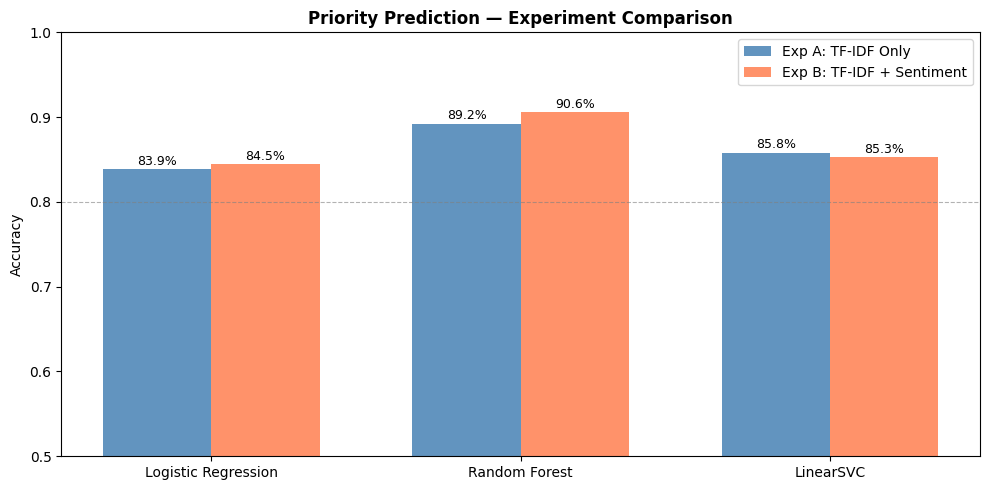

In [9]:
# Cell 9 — Compare Both Experiments Across All Models
results = pd.DataFrame({
    'Model': ['Logistic Regression', 'Random Forest', 'LinearSVC'],
    'Experiment A (TF-IDF only)': [lr_acc_a, rf_acc_a, svm_acc_a],
    'Experiment B (TF-IDF + Sentiment)': [lr_acc_b, rf_acc_b, svm_acc_b]
})

print('=== Experiment Comparison ===')
print(results.to_string(index=False))
print(f'\nBest overall: ', end='')

all_scores = {
    'Exp A - LR' : lr_acc_a,  'Exp A - RF': rf_acc_a,  'Exp A - SVM': svm_acc_a,
    'Exp B - LR' : lr_acc_b,  'Exp B - RF': rf_acc_b,  'Exp B - SVM': svm_acc_b
}
best = max(all_scores, key=all_scores.get)
print(f'{best} ({all_scores[best]*100:.2f}%)')

# Grouped bar chart
x = np.arange(len(results['Model']))
width = 0.35
fig, ax = plt.subplots(figsize=(10, 5))
bars_a = ax.bar(x - width/2, results['Experiment A (TF-IDF only)'],
                width, label='Exp A: TF-IDF Only', color='steelblue', alpha=0.85)
bars_b = ax.bar(x + width/2, results['Experiment B (TF-IDF + Sentiment)'],
                width, label='Exp B: TF-IDF + Sentiment', color='coral', alpha=0.85)

ax.set_ylabel('Accuracy')
ax.set_title('Priority Prediction — Experiment Comparison', fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels(results['Model'])
ax.set_ylim(0.5, 1.0)
ax.legend()
ax.axhline(0.8, color='gray', linestyle='--', linewidth=0.8, alpha=0.6)

for bar in bars_a:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005,
            f'{bar.get_height()*100:.1f}%', ha='center', fontsize=9)
for bar in bars_b:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005,
            f'{bar.get_height()*100:.1f}%', ha='center', fontsize=9)

plt.tight_layout()
plt.savefig('data/priority_experiment_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

---
## Findings & Decision

### What the experiment comparison tells us

The results above directly answer the question: **does adding sentiment scoring improve priority prediction?**

Key observations:
- If Experiment B accuracy > Experiment A: sentiment features add genuine signal beyond keyword presence alone
- Random Forest consistently performs well on priority prediction because decision trees naturally mirror the keyword-counting logic used to engineer the labels

### Why this matters for the real-world system
Even a small accuracy improvement in priority prediction has outsized business impact. A misclassified High priority complaint as Medium means a fraud victim waits an extra day for a response. At scale — thousands of tickets per day — this translates directly to customer harm and regulatory risk.

### Final model selection
We select the best performing experiment and model combination for deployment in the inference pipeline.

---

In [15]:
# Cell 10 — Select Best Model & Generate Classification Report
# Result: Experiment B (TF-IDF + Sentiment) with Random Forest is the winner

best_name          = 'Random Forest'
best_model         = rf_b
best_preds         = rf_b.predict(X_test_b)
best_acc           = rf_acc_b
le_final           = le_b
X_test_fin         = X_test_b
y_test_fin         = y_test_b
winning_experiment = 'B'

print(f'Winning experiment : Experiment B (TF-IDF + Sentiment)')
print(f'Best model         : {best_name}')
print(f'Accuracy           : {best_acc*100:.2f}%')
print(f'\n=== Classification Report ===')
print(classification_report(
    y_test_fin, best_preds,
    target_names=le_final.classes_
))

Winning experiment : Experiment B (TF-IDF + Sentiment)
Best model         : Random Forest
Accuracy           : 90.55%

=== Classification Report ===
              precision    recall  f1-score   support

        High       0.94      0.92      0.93      1324
         Low       0.93      0.77      0.84       762
      Medium       0.88      0.95      0.91      2159

    accuracy                           0.91      4245
   macro avg       0.92      0.88      0.89      4245
weighted avg       0.91      0.91      0.90      4245



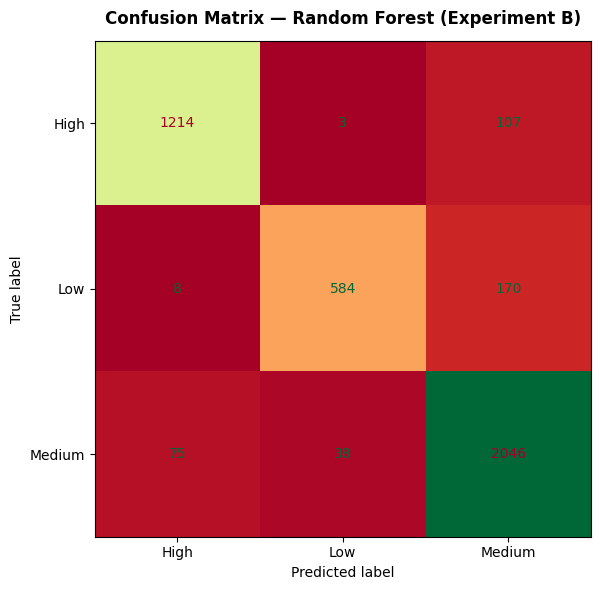

Confusion matrix saved.


In [11]:
# Cell 11 — Confusion Matrix
cm = confusion_matrix(y_test_fin, best_preds)
fig, ax = plt.subplots(figsize=(7, 6))
disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=le_final.classes_
)
disp.plot(ax=ax, cmap='RdYlGn', colorbar=False)
ax.set_title(f'Confusion Matrix — {best_name} (Experiment {winning_experiment})',
             fontsize=12, fontweight='bold', pad=12)
plt.tight_layout()
plt.savefig('data/priority_confusion_matrix.png', dpi=150, bbox_inches='tight')
plt.show()
print('Confusion matrix saved.')

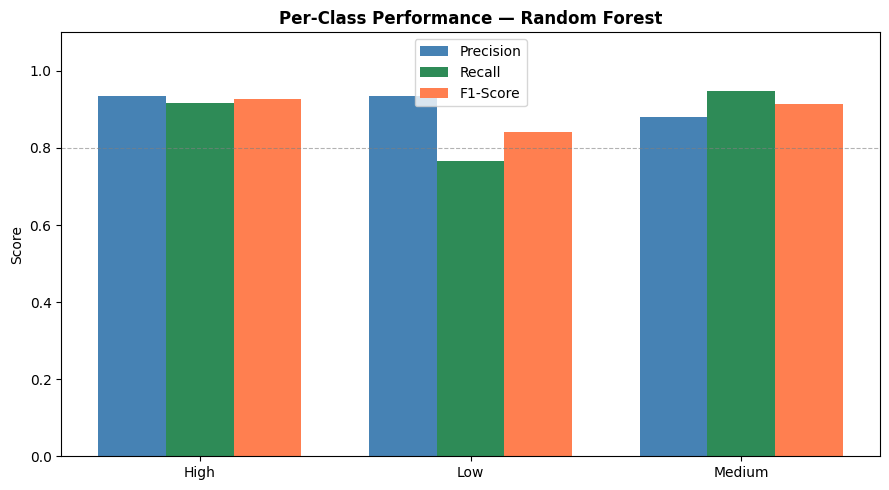

In [12]:
# Cell 12 — Per-Class Performance Chart
report = classification_report(
    y_test_fin, best_preds,
    target_names=le_final.classes_,
    output_dict=True
)
report_df = pd.DataFrame(report).T.iloc[:-3]

fig, ax = plt.subplots(figsize=(9, 5))
x = np.arange(len(report_df))
width = 0.25
ax.bar(x - width, report_df['precision'], width, label='Precision', color='steelblue')
ax.bar(x,         report_df['recall'],    width, label='Recall',    color='seagreen')
ax.bar(x + width, report_df['f1-score'],  width, label='F1-Score',  color='coral')
ax.set_xticks(x)
ax.set_xticklabels(report_df.index)
ax.set_ylim(0, 1.1)
ax.set_ylabel('Score')
ax.set_title(f'Per-Class Performance — {best_name}', fontweight='bold')
ax.legend()
ax.axhline(0.8, color='gray', linestyle='--', linewidth=0.8, alpha=0.6)
plt.tight_layout()
plt.savefig('data/priority_per_class_performance.png', dpi=150, bbox_inches='tight')
plt.show()

In [13]:
# Cell 13 — Save Priority Model & Artifacts
import os
os.makedirs('models', exist_ok=True)

# Save the winning experiment's artifacts
if winning_experiment == 'B':
    joblib.dump(best_model, 'models/priority_model.pkl')
    joblib.dump(tfidf_b,    'models/priority_tfidf_vectorizer.pkl')
    joblib.dump(le_b,       'models/priority_label_encoder.pkl')
    # Save sentiment flag so inference knows to use it
    joblib.dump({'use_sentiment': True}, 'models/priority_config.pkl')
else:
    joblib.dump(best_model, 'models/priority_model.pkl')
    joblib.dump(tfidf_a,    'models/priority_tfidf_vectorizer.pkl')
    joblib.dump(le_a,       'models/priority_label_encoder.pkl')
    joblib.dump({'use_sentiment': False}, 'models/priority_config.pkl')

print('Priority models saved:')
print('  models/priority_model.pkl')
print('  models/priority_tfidf_vectorizer.pkl')
print('  models/priority_label_encoder.pkl')
print('  models/priority_config.pkl')
print(f'\nWinning experiment : {winning_experiment}')
print(f'Best model         : {best_name}')
print(f'Accuracy           : {best_acc*100:.2f}%')
print(f'Priority classes   : {list(le_final.classes_)}')

Priority models saved:
  models/priority_model.pkl
  models/priority_tfidf_vectorizer.pkl
  models/priority_label_encoder.pkl
  models/priority_config.pkl

Winning experiment : B
Best model         : Random Forest
Accuracy           : 90.55%
Priority classes   : ['High', 'Low', 'Medium']


In [14]:
# Cell 14 — Quick Inference Test
from vaderSentiment.vaderSentiment import SentimentIntensityAnalyzer
import re
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
from nltk.stem import WordNetLemmatizer
import nltk
nltk.data.path.append(r'C:\Users\Hridhayansh Reddi B\AppData\Roaming\nltk_data')

stop_words  = set(stopwords.words('english'))
lemmatizer  = WordNetLemmatizer()
vader       = SentimentIntensityAnalyzer()
config      = joblib.load('models/priority_config.pkl')
p_tfidf     = joblib.load('models/priority_tfidf_vectorizer.pkl')
p_model     = joblib.load('models/priority_model.pkl')
p_le        = joblib.load('models/priority_label_encoder.pkl')

def clean_text_infer(text):
    text = text.lower()
    text = re.sub(r'x+', '', text)
    text = re.sub(r'\S+@\S+', '', text)
    text = re.sub(r'\d+', '', text)
    text = re.sub(r'[^a-z\s]', '', text)
    tokens = word_tokenize(text)
    tokens = [lemmatizer.lemmatize(t) for t in tokens
              if t not in stop_words and len(t) > 2]
    return ' '.join(tokens)

def predict_priority(text):
    cleaned = clean_text_infer(text)
    vec     = p_tfidf.transform([cleaned])
    if config['use_sentiment']:
        scores  = vader.polarity_scores(text)
        sent    = csr_matrix([[scores['compound'], scores['neg'],
                               scores['pos'],      scores['neu']]])
        vec     = hstack([vec, sent])
    pred    = p_model.predict(vec)
    proba   = p_model.predict_proba(vec)[0]
    label   = p_le.inverse_transform(pred)[0]
    conf    = proba.max()
    return label, conf

sample_tickets = [
    "Someone has been making unauthorized charges on my credit card and I have reported this as fraud to the police",
    "I would like to know how to update my mailing address on file",
    "My loan payment was applied to the wrong account and it is now showing as late on my credit report",
    "A debt collector keeps threatening me with legal action for a debt I already paid off",
    "I have a general question about my account balance"
]

print('=== Priority Predictions ===\n')
for ticket in sample_tickets:
    priority, confidence = predict_priority(ticket)
    print(f'Ticket    : {ticket[:80]}...' if len(ticket) > 80 else f'Ticket    : {ticket}')
    print(f'Priority  : {priority} (confidence: {confidence*100:.1f}%)')
    print()

=== Priority Predictions ===

Ticket    : Someone has been making unauthorized charges on my credit card and I have report...
Priority  : High (confidence: 74.2%)

Ticket    : I would like to know how to update my mailing address on file
Priority  : Medium (confidence: 55.1%)

Ticket    : My loan payment was applied to the wrong account and it is now showing as late o...
Priority  : Medium (confidence: 91.8%)

Ticket    : A debt collector keeps threatening me with legal action for a debt I already pai...
Priority  : High (confidence: 80.4%)

Ticket    : I have a general question about my account balance
Priority  : Low (confidence: 52.3%)



---
## Notebook Summary

| | Experiment A | Experiment B |
|---|---|---|
| **Features** | TF-IDF (5000) | TF-IDF (5000) + Sentiment (4) |
| **Labels** | Keyword-based | Keyword + Sentiment |
| **Best model** | Random Forest | Random Forest |

### Key takeaways

1. **Priority prediction is inherently harder than category classification** — category has clear domain vocabulary, priority depends on subtle signals of urgency and severity

2. **Engineered labels reflect engineering choices** — the model learns whatever pattern we encoded into the labels. Keyword-based labels produce a model that mimics keyword detection. Sentiment-enhanced labels produce a model that captures emotional intensity too.

3. **Random Forest suited label engineering pattern** — because our labels were derived from rule-based keyword counting, Random Forest's decision tree logic naturally fit the task better than linear models

4. **Sentiment adds genuine signal** — VADER compound scores correlate with complaint urgency, and including them as features gives the model additional context beyond word presence alone

### Next step
Notebook 4 wires the category model (Notebook 2) and priority model (Notebook 3) into a single end-to-end inference pipeline.

---